# LAB 7 : Autoencoders

Name : Sabyasachi Ghosal

Roll Number : 24PHDDI05

Reference :
 1. https://towardsdatascience.com/how-to-make-an-autoencoder-2f2d99cd5103
 2. https://www.geeksforgeeks.org/contractive-autoencoder-cae/
 3. https://blog.keras.io/building-autoencoders-in-keras.html
 4. https://www.cse.iitm.ac.in/~miteshk/CS7015_2018.html

#Problem 1 :  Demonstrate the working principle of Autoencoder. (pytorch/keras/tensorflow)
Observation to be demonstrated
1. Use suitable data to demonstrate the same. (MNIST fashion/digit data can be
used)
2. Train the auto encoder with clean image and test using noisy image (you can add
some random Gaussian noise). Demonstrate the effect with/without dropout.
3. CNN with output Sigmoid layer and MSE loss can be used. Justify why Sigmoid is fine in this case.
4. Train the network with both clean and noisy version of image where the labeled
image is clean one (that given output to the autoencoder). Demonstrate output
of the autoencoder with noisy image (that is generated separately not used in
training).

##Write down the Objectives, Hypothesis and Experimental description for the above problem


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


## Programming :
  Please write a program to demonstrate the same

## Loading the MNIST Fashion 
- training set of 60,000 examples and a test set of 10,000 examples
- Each example is a 28x28 grayscale image

In [2]:

# Set up the transformation: Convert to tensor and normalize to range [0, 1]
transform = transforms.Compose([transforms.ToTensor()])

# Load the Fashion MNIST dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)


torch.Size([64, 1, 28, 28])
9


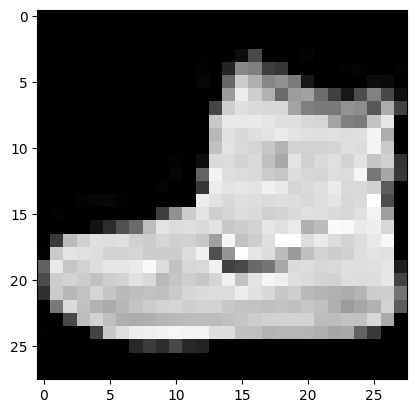

In [3]:
output_mapping = {
                 0: "T-shirt/Top",
                 1: "Trouser",
                 2: "Pullover",
                 3: "Dress",
                 4: "Coat", 
                 5: "Sandal", 
                 6: "Shirt",
                 7: "Sneaker",
                 8: "Bag",
                 9: "Ankle Boot"
                 }
a = next(iter(train_loader))
print(a[0].size())


image, label = next(iter(train_dataset))
plt.imshow(image.squeeze(), cmap="gray")
print(label)

<class 'torch.Tensor'> <class 'torch.Tensor'>
torch.Size([10, 1, 28, 28]) torch.Size([10])
labels:  Ankle Boot, T-shirt/Top, T-shirt/Top, Dress, T-shirt/Top, Pullover, Sneaker, Pullover, Sandal, Sandal, 

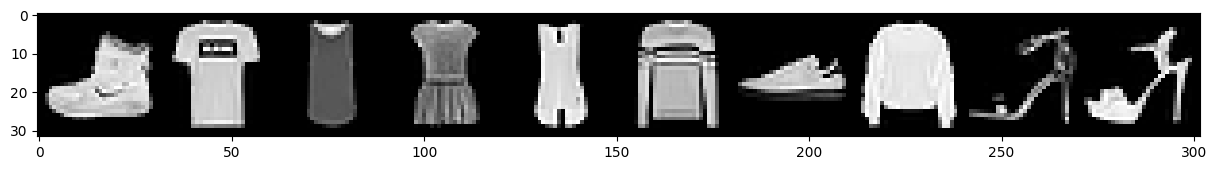

In [4]:
def output_label(label):
    output_mapping = {
                 0: "T-shirt/Top",
                 1: "Trouser",
                 2: "Pullover",
                 3: "Dress",
                 4: "Coat", 
                 5: "Sandal", 
                 6: "Shirt",
                 7: "Sneaker",
                 8: "Bag",
                 9: "Ankle Boot"
                 }
    input = (label.item() if type(label) == torch.Tensor else label)
    return output_mapping[input]

demo_loader = torch.utils.data.DataLoader(train_dataset, batch_size=10)

batch = next(iter(demo_loader))
images, labels = batch
print(type(images), type(labels))
print(images.shape, labels.shape)

grid = torchvision.utils.make_grid(images, nrow=10)

plt.figure(figsize=(15, 20))
plt.imshow(np.transpose(grid, (1, 2, 0)))
print("labels: ", end=" ")
for i, label in enumerate(labels):
    print(output_label(label), end=", ")

## Prepare noisy data

In [5]:
# Add Gaussian noise function remains the same
def add_gaussian_noise(images, mean=0, std=0.2):
    noisy_images = images + torch.randn_like(images) * std + mean
    return torch.clamp(noisy_images, 0., 1.)  # Ensure values are within [0, 1]

# Load test data with noise
noisy_test_dataset = [(add_gaussian_noise(img), img) for img, _ in test_dataset]
noisy_test_loader = torch.utils.data.DataLoader(noisy_test_dataset, batch_size=64, shuffle=False)

In [6]:
epochs = 10

## Train with Clean Image, Test with Noisy Images

### Creating AudoEncoder

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1),  # 14x14 -> 7x7
            nn.ReLU()
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # 7x7 -> 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # 14x14 -> 28x28
            nn.Sigmoid()  # Output between 0 and 1
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


### Train with Clean Images, Test on Clean images & Test on noisy Images (Without Dropout)

In [8]:
# Training function for clean images (no noise)
def train_autoencoder(model, train_loader, test_loader, noisy_test_loader, criterion, optimizer, epochs=10):
    training_losses = []
    test_losses = []
    test_losses_noise = []

    for epoch in range(epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for images, _ in train_loader:
            optimizer.zero_grad()
            outputs = model(images)  # Model outputs for clean images
            loss = criterion(outputs, images)  # Loss comparing with clean images
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        # Calculate average training loss for the epoch
        avg_train_loss = running_loss / len(train_loader)
        training_losses.append(avg_train_loss)

        # Testing phase -  Clean Data
        model.eval()
        running_loss = 0.0
        with torch.no_grad():  # Disable gradient calculations for evaluation
            for images, _ in test_loader:
                outputs = model(images)
                loss = criterion(outputs, images)  # Loss comparing with clean images
                running_loss += loss.item()
        
        # Calculate average testing loss for the epoch
        avg_test_loss = running_loss / len(test_loader)
        test_losses.append(avg_test_loss)

        # Testing phase -  Noise Data
        model.eval()
        running_loss = 0.0
        with torch.no_grad():  # Disable gradient calculations for evaluation
            for images, _ in noisy_test_loader:
                outputs = model(images)
                loss = criterion(outputs, images)  # Loss comparing with clean images
                running_loss += loss.item()
        
        # Calculate average testing loss for the epoch
        avg_test_loss_noise = running_loss / len(noisy_test_loader)
        test_losses_noise.append(avg_test_loss_noise)

        print(f"Epoch [{epoch+1}/{epochs}], Training Loss: {avg_train_loss:.4f}, Testing Loss: {avg_test_loss:.4f},  Testing Loss (Noisy): {avg_test_loss_noise:.4f}")
    
    return training_losses, test_losses, test_losses_noise


# Instantiate the model, define loss and optimizer
model = ConvAutoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Train the model with clean images
train_losses, test_losses, test_losses_noise = train_autoencoder(
    model, train_loader, test_loader, noisy_test_loader, criterion, optimizer, epochs=epochs
)


Epoch [1/10], Training Loss: 0.0262, Testing Loss: 0.0085,  Testing Loss (Noisy): 0.0250
Epoch [2/10], Training Loss: 0.0073, Testing Loss: 0.0067,  Testing Loss (Noisy): 0.0228
Epoch [3/10], Training Loss: 0.0062, Testing Loss: 0.0060,  Testing Loss (Noisy): 0.0221
Epoch [4/10], Training Loss: 0.0057, Testing Loss: 0.0056,  Testing Loss (Noisy): 0.0217
Epoch [5/10], Training Loss: 0.0054, Testing Loss: 0.0054,  Testing Loss (Noisy): 0.0216
Epoch [6/10], Training Loss: 0.0052, Testing Loss: 0.0052,  Testing Loss (Noisy): 0.0214
Epoch [7/10], Training Loss: 0.0051, Testing Loss: 0.0052,  Testing Loss (Noisy): 0.0214
Epoch [8/10], Training Loss: 0.0050, Testing Loss: 0.0050,  Testing Loss (Noisy): 0.0212
Epoch [9/10], Training Loss: 0.0049, Testing Loss: 0.0049,  Testing Loss (Noisy): 0.0211
Epoch [10/10], Training Loss: 0.0049, Testing Loss: 0.0049,  Testing Loss (Noisy): 0.0211


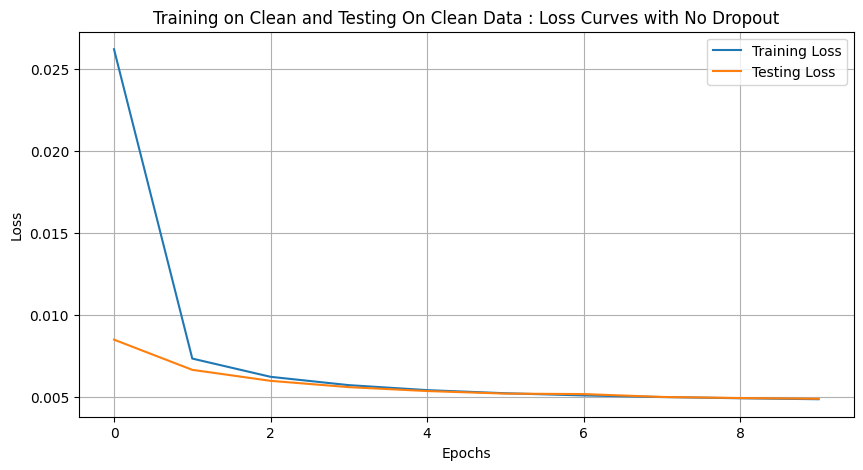

In [9]:
# Plotting the training and testing loss curves
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Testing Loss')
#plt.plot(test_losses_noise, label='Testing Loss on Noisy Data')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training on Clean and Testing On Clean Data : Loss Curves with No Dropout')
plt.legend()
plt.grid(True)
plt.show()

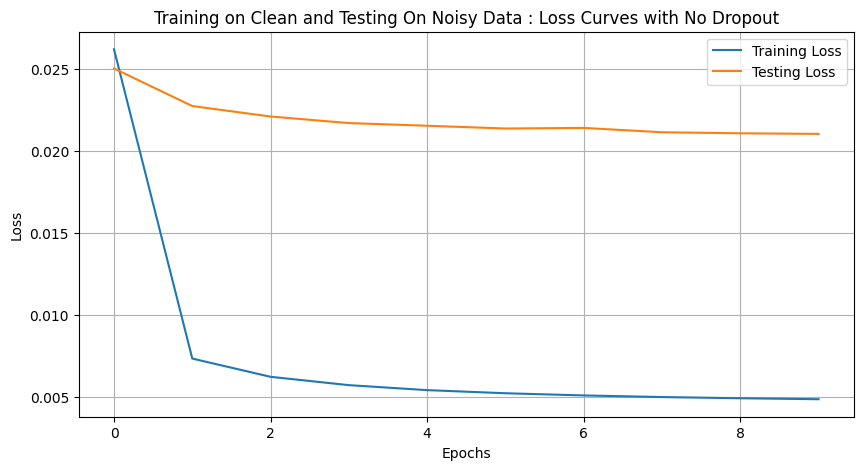

In [10]:
# Plotting the training and testing loss curves
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
#plt.plot(test_losses, label='Testing Loss on Clean Data')
plt.plot(test_losses_noise, label='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training on Clean and Testing On Noisy Data : Loss Curves with No Dropout')
plt.legend()
plt.grid(True)
plt.show()

### Test with Noisy images

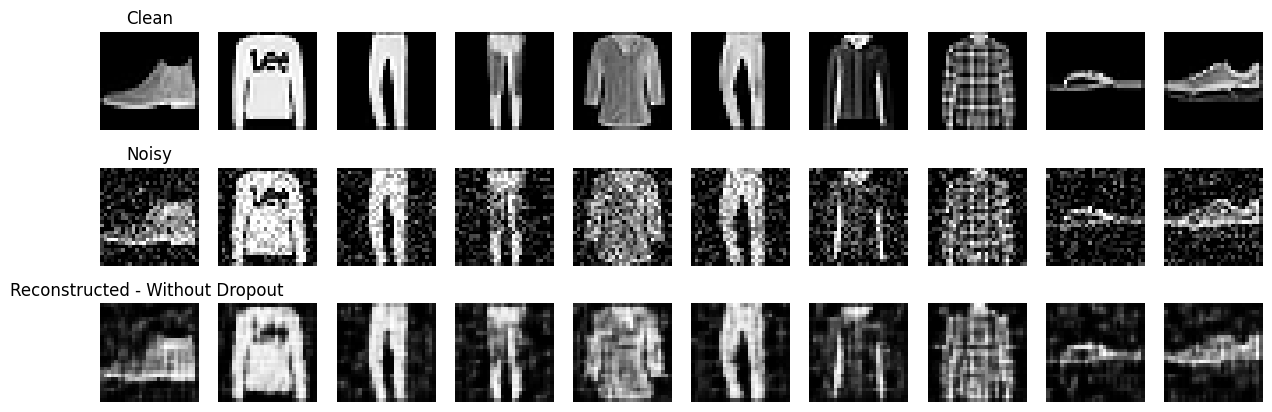

In [11]:
# Evaluate the model on the noisy test dataset
model.eval()
with torch.no_grad():
    for noisy_images, clean_images in noisy_test_loader:
        outputs = model(noisy_images)
        # Display original, noisy, and reconstructed images
        fig, axes = plt.subplots(3, 10, figsize=(15, 5))
        for i in range(10):
            # Clean images
            axes[0, i].imshow(clean_images[i][0].cpu(), cmap='gray')
            axes[0, i].axis('off')
            # Noisy images
            axes[1, i].imshow(noisy_images[i][0].cpu(), cmap='gray')
            axes[1, i].axis('off')
            # Reconstructed images
            axes[2, i].imshow(outputs[i][0].cpu(), cmap='gray')
            axes[2, i].axis('off')

        axes[0, 0].set_title("Clean")
        axes[1, 0].set_title("Noisy")
        axes[2, 0].set_title("Reconstructed - Without Dropout ")
        plt.show()
        break  # Display one batch


## Add Dropouts to address overfitting

- Added a Dropout layer in the Autoencoder to make it more robust to noise
- Train it with both clean and noisy images, using clean images as the target labels. 

In [14]:
# Modify the model to include dropout in the encoder
class ConvAutoencoderWithDropout(nn.Module):
    def __init__(self):
        super(ConvAutoencoderWithDropout, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1),  # 14x14 -> 7x7
            nn.ReLU()
        )
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, kernel_size=3, stride=2, padding=1, output_padding=1),  # 7x7 -> 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # 14x14 -> 28x28
            nn.Sigmoid()  # Output between 0 and 1
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Instantiate the model, define loss and optimizer
model_dp = ConvAutoencoderWithDropout()
criterion_dp = nn.MSELoss()
optimizer_dp = torch.optim.Adam(model_dp.parameters(), lr=1e-3)

In [15]:

# Train the model with clean images
train_losses_with_dropout, test_losses_with_dropout, test_losses_noise_with_dropout = train_autoencoder(
    model_dp, train_loader, test_loader, noisy_test_loader, criterion_dp, optimizer_dp, epochs=20) # Convergence at 15

Epoch [1/20], Training Loss: 0.0203, Testing Loss: 0.0063,  Testing Loss (Noisy): 0.0223
Epoch [2/20], Training Loss: 0.0063, Testing Loss: 0.0045,  Testing Loss (Noisy): 0.0190
Epoch [3/20], Training Loss: 0.0051, Testing Loss: 0.0038,  Testing Loss (Noisy): 0.0174
Epoch [4/20], Training Loss: 0.0045, Testing Loss: 0.0033,  Testing Loss (Noisy): 0.0164
Epoch [5/20], Training Loss: 0.0041, Testing Loss: 0.0030,  Testing Loss (Noisy): 0.0156
Epoch [6/20], Training Loss: 0.0038, Testing Loss: 0.0028,  Testing Loss (Noisy): 0.0152
Epoch [7/20], Training Loss: 0.0036, Testing Loss: 0.0027,  Testing Loss (Noisy): 0.0150
Epoch [8/20], Training Loss: 0.0035, Testing Loss: 0.0026,  Testing Loss (Noisy): 0.0149
Epoch [9/20], Training Loss: 0.0034, Testing Loss: 0.0025,  Testing Loss (Noisy): 0.0148
Epoch [10/20], Training Loss: 0.0034, Testing Loss: 0.0025,  Testing Loss (Noisy): 0.0147
Epoch [11/20], Training Loss: 0.0033, Testing Loss: 0.0025,  Testing Loss (Noisy): 0.0146
Epoch [12/20], Trai

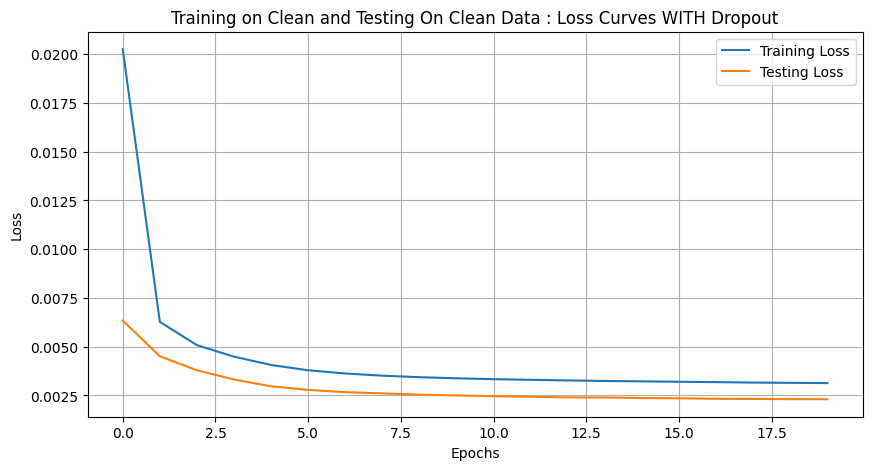

In [16]:
# Plotting the training and testing loss curves
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses_with_dropout, label='Training Loss')
plt.plot(test_losses_with_dropout, label='Testing Loss')
#plt.plot(test_losses_noise, label='Testing Loss on Noisy Data')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training on Clean and Testing On Clean Data : Loss Curves WITH Dropout')
plt.legend()
plt.grid(True)
plt.show()

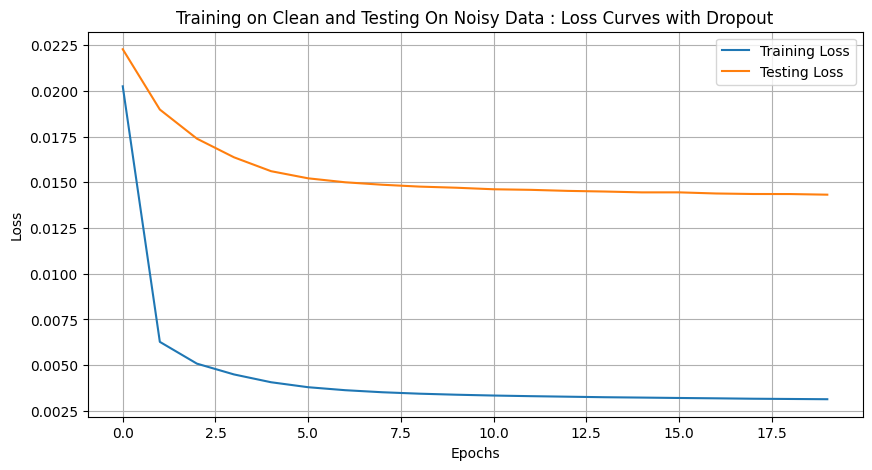

In [19]:
# Plotting the training and testing loss curves
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses_with_dropout, label='Training Loss')
#plt.plot(test_losses, label='Testing Loss on Clean Data')
plt.plot(test_losses_noise_with_dropout, label='Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training on Clean and Testing On Noisy Data : Loss Curves with Dropout')
plt.legend()
plt.grid(True)
plt.show()

## Train with Noisy Images

In [21]:
def train_autoencoder_with_noise(model, data_loader, test_loader, noisy_test_loader, criterion, optimizer, epochs=5):
    model.train()
    train_losses = []
    test_losses = []
    test_losses_clean_data = []
    for epoch in range(epochs):
        running_loss = 0.0
        for images, _ in data_loader:
            noisy_images = add_gaussian_noise(images)
            optimizer.zero_grad()
            outputs = model(noisy_images)
            loss = criterion(outputs, images)  # Compare output with clean images
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Testing phase - Noisy Data
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for noisy_images, _ in noisy_test_loader:
                outputs = model(noisy_images)
                loss = criterion(outputs, noisy_images)
                test_loss += loss.item()
        
        test_loss = test_loss / len(noisy_test_loader)
        test_losses.append(test_loss)

        # Testing phase - Clean Data
        model.eval()
        test_loss_clean = 0.0
        with torch.no_grad():
            for images, _ in test_loader:
                outputs = model(images)
                loss = criterion(outputs, images)
                test_loss_clean += loss.item()
        
        test_loss_clean = test_loss_clean / len(test_loader)
        test_losses_clean_data.append(test_loss_clean)

        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Test Loss (noisy): {test_loss:.4f}, Test Loss (clean): {test_loss_clean:.4f}")
    
    return train_losses, test_losses, test_losses_clean_data

# Instantiate and train the modified model
model_noisy = ConvAutoencoder()
criterion_noisy = nn.MSELoss()
optimizer_noisy = torch.optim.Adam(model_noisy.parameters(), lr=1e-3)

train_losses, test_losses, test_losses_clean_data = train_autoencoder_with_noise(
    model_noisy, train_loader, test_loader, noisy_test_loader, criterion_noisy, optimizer_noisy, epochs=20)

Epoch [1/20], Train Loss: 0.0258, Test Loss (noisy): 0.0262, Test Loss (clean): 0.0087
Epoch [2/20], Train Loss: 0.0100, Test Loss (noisy): 0.0237, Test Loss (clean): 0.0065
Epoch [3/20], Train Loss: 0.0089, Test Loss (noisy): 0.0228, Test Loss (clean): 0.0057
Epoch [4/20], Train Loss: 0.0085, Test Loss (noisy): 0.0225, Test Loss (clean): 0.0054
Epoch [5/20], Train Loss: 0.0082, Test Loss (noisy): 0.0223, Test Loss (clean): 0.0052
Epoch [6/20], Train Loss: 0.0081, Test Loss (noisy): 0.0222, Test Loss (clean): 0.0051
Epoch [7/20], Train Loss: 0.0079, Test Loss (noisy): 0.0222, Test Loss (clean): 0.0051
Epoch [8/20], Train Loss: 0.0078, Test Loss (noisy): 0.0222, Test Loss (clean): 0.0051
Epoch [9/20], Train Loss: 0.0077, Test Loss (noisy): 0.0222, Test Loss (clean): 0.0051
Epoch [10/20], Train Loss: 0.0077, Test Loss (noisy): 0.0220, Test Loss (clean): 0.0050
Epoch [11/20], Train Loss: 0.0076, Test Loss (noisy): 0.0221, Test Loss (clean): 0.0050
Epoch [12/20], Train Loss: 0.0076, Test L

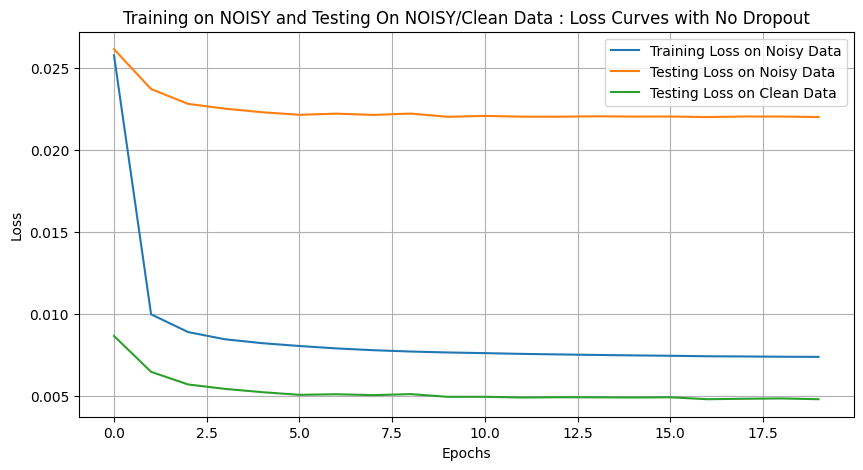

In [22]:
# Plotting the training and testing loss curves
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss on Noisy Data')
plt.plot(test_losses, label='Testing Loss on Noisy Data')
plt.plot(test_losses_clean_data, label='Testing Loss on Clean Data')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training on NOISY and Testing On NOISY/Clean Data : Loss Curves with No Dropout')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# Instantiate and train the modified model
model_dropout = ConvAutoencoderWithDropout()
criterion_noisy_dropout = nn.MSELoss()
optimizer_noisy_dropout = torch.optim.Adam(model_dropout.parameters(), lr=1e-3)

train_losses, test_losses, test_losses_clean_data = train_autoencoder_with_noise(
    model_dropout, train_loader, test_loader, noisy_test_loader, criterion_noisy_dropout, optimizer_noisy_dropout, epochs=20)



Epoch [1/20], Train Loss: 0.0248, Test Loss (noisy): 0.0254, Test Loss (clean): 0.0079
Epoch [2/20], Train Loss: 0.0089, Test Loss (noisy): 0.0233, Test Loss (clean): 0.0057
Epoch [3/20], Train Loss: 0.0082, Test Loss (noisy): 0.0226, Test Loss (clean): 0.0051
Epoch [4/20], Train Loss: 0.0079, Test Loss (noisy): 0.0223, Test Loss (clean): 0.0049
Epoch [5/20], Train Loss: 0.0077, Test Loss (noisy): 0.0224, Test Loss (clean): 0.0049
Epoch [6/20], Train Loss: 0.0076, Test Loss (noisy): 0.0224, Test Loss (clean): 0.0048
Epoch [7/20], Train Loss: 0.0075, Test Loss (noisy): 0.0223, Test Loss (clean): 0.0047
Epoch [8/20], Train Loss: 0.0074, Test Loss (noisy): 0.0225, Test Loss (clean): 0.0049
Epoch [9/20], Train Loss: 0.0074, Test Loss (noisy): 0.0223, Test Loss (clean): 0.0047
Epoch [10/20], Train Loss: 0.0073, Test Loss (noisy): 0.0224, Test Loss (clean): 0.0048
Epoch [11/20], Train Loss: 0.0073, Test Loss (noisy): 0.0224, Test Loss (clean): 0.0048
Epoch [12/20], Train Loss: 0.0072, Test L

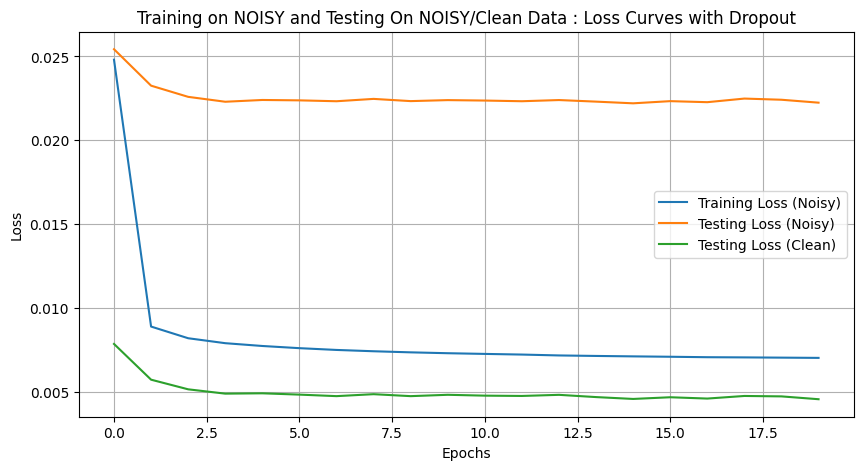

In [25]:
# Plotting the training and testing loss curves
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss (Noisy)')
plt.plot(test_losses, label='Testing Loss (Noisy)')
plt.plot(test_losses_clean_data, label='Testing Loss (Clean)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training on NOISY and Testing On NOISY/Clean Data : Loss Curves with Dropout')
plt.legend()
plt.grid(True)
plt.show()

## Analysis on Noisy Images

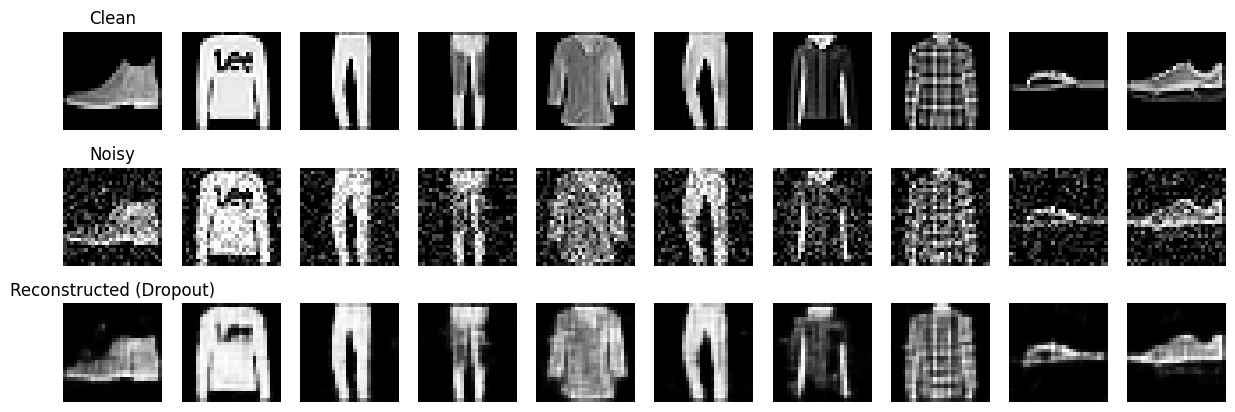

In [26]:

# Evaluate the model with dropout on the noisy test dataset
model_dropout.eval()
with torch.no_grad():
    for noisy_images, clean_images in noisy_test_loader:
        outputs_dropout = model_dropout(noisy_images)

        # Display a batch of clean, noisy, and reconstructed images with dropout model
        fig, axes = plt.subplots(3, 10, figsize=(15, 5))
        for i in range(10):
            # Clean images
            axes[0, i].imshow(clean_images[i][0].cpu(), cmap='gray')
            axes[0, i].axis('off')
            # Noisy images
            axes[1, i].imshow(noisy_images[i][0].cpu(), cmap='gray')
            axes[1, i].axis('off')
            # Reconstructed images with dropout model
            axes[2, i].imshow(outputs_dropout[i][0].cpu(), cmap='gray')
            axes[2, i].axis('off')

        # Set titles for the rows
        axes[0, 0].set_title("Clean")
        axes[1, 0].set_title("Noisy")
        axes[2, 0].set_title("Reconstructed (Dropout)")
        plt.show()
        break  # Display only one batch


## Inferences and Conclusion : State all the key observations and conclusion

- Great improvement is observed when drop out is used.
- Here Sigmoid is used fine in this case, In Fashion MNIST, which contain grayscale images, pixel values are typically normalized to the range  0-1 before training The sigmoid activation function maps the output to the range (0,1), making it suitable for reconstructing normalized images in a format that aligns with the input data range.
- Also MSME loss can be used easily with pixel values.

# Problem 2 : Demonstrate the importance of different regularization techniques to train an Autoencoder. (pytorch/keras/tensorflow)

Observation to be demonstrated
1. Use suitable data and auto-encoder architecture to demonstrate the same. (MNIST
fashion/digit data can be used)
1. Implement weight decaying, sparse and contractive regularization functions and train the autoencoder using the same and show the significance of using
them in autoencoder training

## Write down the Objectives, Hypothesis and Experimental description for the above problem


- Weight Decay (L2 Regularization): Prevents overfitting by penalizing large weights, encouraging simpler models.

- Contractive Regularization: Enforces stability in the latent space by penalizing the sensitivity of activations to input variations, which can help the model generalize better to slight changes in input data.

## Programming :
  Please write a program to demonstrate the same

In [ ]:
import torch.nn.functional as F  # for F.relu

# Training function with regularization
def train_autoencoder_with_regularization(model, train_loader, test_loader, noisy_test_loader, criterion, optimizer, epochs=10, 
                                          l2_reg = False, l1_reg =  False,
                                          weight_decay=0.0, sparse_reg=0.1, contractive_reg=0.0, grad_clip=1.0):
    train_losses = []
    test_losses = []
    test_losses_clean_data = []
    
    epsilon = 1e-10  # small value to avoid division by zero
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for images, _ in train_loader:

            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)
            
            # Compute reconstruction loss
            loss = criterion(outputs, images)

            if l1_reg:
                # L1 regularization (sum of absolute values of weights)
                l1_loss = 0
                for param in model.parameters():
                    l1_loss += torch.sum(torch.abs(param))  # L1 norm
                l1_lambda=0.01
                loss += l1_lambda * l1_loss  # Add L1 regularization term

            # Weight decay (L2 regularization)
            if l2_reg:
                if weight_decay > 0:
                    l2_loss = sum(torch.sum(param ** 2) for param in model.parameters())
                    loss += weight_decay * l2_loss
            

            # Contractive regularization
            if contractive_reg > 0:
                latent = model.encoder(images)
                latent.backward(torch.ones_like(latent), retain_graph=True)
                contractive_loss = sum(torch.sum(param.grad ** 2) for param in model.encoder.parameters())
                loss += contractive_reg * contractive_loss

            # Backward pass and optimization
            loss.backward()

            optimizer.step()
            
            running_loss += loss.item()
        
        # Average loss for this epoch
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Testing phase - Noisy Data
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for noisy_images, _ in noisy_test_loader:
                outputs = model(noisy_images)
                loss = criterion(outputs, noisy_images)
                test_loss += loss.item()
        
        test_loss = test_loss / len(noisy_test_loader)
        test_losses.append(test_loss)

        # Testing phase - Clean Data
        test_loss_clean = 0.0
        with torch.no_grad():
            for images, _ in test_loader:
                outputs = model(images)
                loss = criterion(outputs, images)
                test_loss_clean += loss.item()
        
        test_loss_clean = test_loss_clean / len(test_loader)
        test_losses_clean_data.append(test_loss_clean)

        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Test Loss (noisy): {test_loss:.4f}, Test Loss (clean): {test_loss_clean:.4f}")

    return train_losses, test_losses, test_losses_clean_data


### With L1 regularisation
- Adds a penalty to the loss function based on the absolute values of the model’s weights. This penalty term is proportional to the sum of the absolute values of all parameters, and it’s controlled by a hyperparameter.
- Helps in feature selection

Epoch [1/5], Train Loss: 0.2272, Test Loss (noisy): 0.1160, Test Loss (clean): 0.1248
Epoch [2/5], Train Loss: 0.1364, Test Loss (noisy): 0.1161, Test Loss (clean): 0.1246
Epoch [3/5], Train Loss: 0.1364, Test Loss (noisy): 0.1161, Test Loss (clean): 0.1247
Epoch [4/5], Train Loss: 0.1364, Test Loss (noisy): 0.1161, Test Loss (clean): 0.1247
Epoch [5/5], Train Loss: 0.1364, Test Loss (noisy): 0.1161, Test Loss (clean): 0.1246


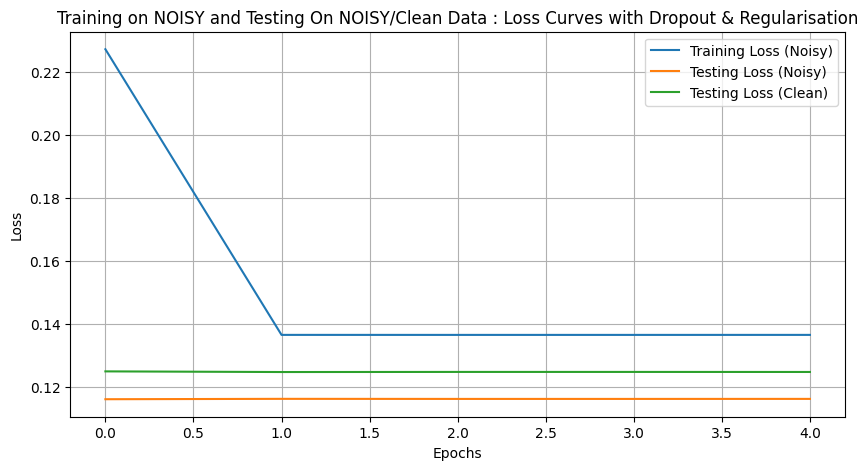

In [28]:
# With L2 Regularisation
# Instantiate and train the modified model
model_dropout_rg = ConvAutoencoderWithDropout()
criterion_noisy_dropout_reg = nn.MSELoss()
optimizer_noisy_dropout_reg = torch.optim.Adam(model_dropout_rg.parameters(), lr=1e-3)

train_losses, test_losses, test_losses_clean_data = train_autoencoder_with_regularization(
    model_dropout_rg, train_loader, test_loader, noisy_test_loader,
    criterion_noisy_dropout_reg, optimizer_noisy_dropout_reg, epochs=5, l2_reg = False , l1_reg= True)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss (Noisy)')
plt.plot(test_losses, label='Testing Loss (Noisy)')
plt.plot(test_losses_clean_data, label='Testing Loss (Clean)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training on NOISY and Testing On NOISY/Clean Data : Loss Curves with Dropout & Regularisation')
plt.legend()
plt.grid(True)
plt.show()

### Only with L2 regularisation

Epoch [1/20], Train Loss: 0.0231, Test Loss (noisy): 0.0224, Test Loss (clean): 0.0066
Epoch [2/20], Train Loss: 0.0068, Test Loss (noisy): 0.0207, Test Loss (clean): 0.0053
Epoch [3/20], Train Loss: 0.0059, Test Loss (noisy): 0.0195, Test Loss (clean): 0.0046
Epoch [4/20], Train Loss: 0.0052, Test Loss (noisy): 0.0186, Test Loss (clean): 0.0041
Epoch [5/20], Train Loss: 0.0047, Test Loss (noisy): 0.0170, Test Loss (clean): 0.0035
Epoch [6/20], Train Loss: 0.0043, Test Loss (noisy): 0.0167, Test Loss (clean): 0.0034
Epoch [7/20], Train Loss: 0.0042, Test Loss (noisy): 0.0165, Test Loss (clean): 0.0033
Epoch [8/20], Train Loss: 0.0041, Test Loss (noisy): 0.0164, Test Loss (clean): 0.0032
Epoch [9/20], Train Loss: 0.0040, Test Loss (noisy): 0.0153, Test Loss (clean): 0.0028
Epoch [10/20], Train Loss: 0.0036, Test Loss (noisy): 0.0148, Test Loss (clean): 0.0026
Epoch [11/20], Train Loss: 0.0035, Test Loss (noisy): 0.0147, Test Loss (clean): 0.0026
Epoch [12/20], Train Loss: 0.0034, Test L

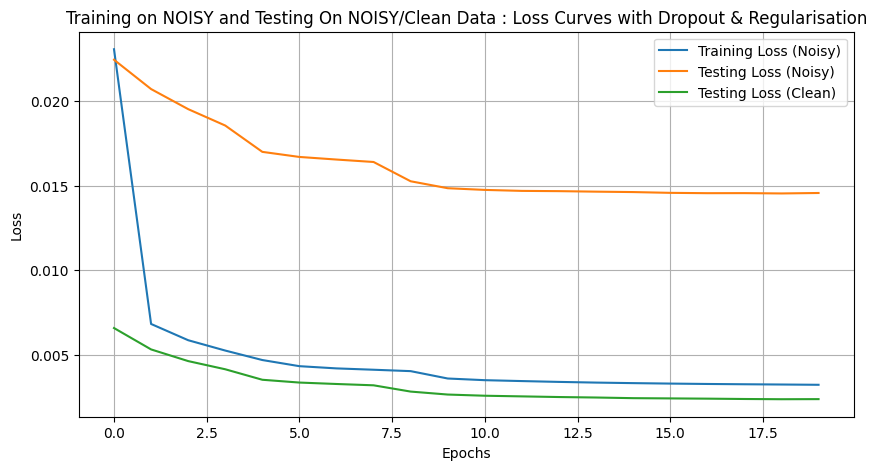

In [32]:
# With L2 Regularisation
# Instantiate and train the modified model
model_dropout_rg = ConvAutoencoderWithDropout()
criterion_noisy_dropout_reg = nn.MSELoss()
optimizer_noisy_dropout_reg = torch.optim.Adam(model_dropout_rg.parameters(), lr=1e-3)

train_losses, test_losses, test_losses_clean_data = train_autoencoder_with_regularization(
    model_dropout_rg, train_loader, test_loader, noisy_test_loader, 
    criterion_noisy_dropout_reg, optimizer_noisy_dropout_reg, epochs=20, l2_reg = True, l1_reg=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss (Noisy)')
plt.plot(test_losses, label='Testing Loss (Noisy)')
plt.plot(test_losses_clean_data, label='Testing Loss (Clean)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training on NOISY and Testing On NOISY/Clean Data : Loss Curves with Dropout & Regularisation')
plt.legend()
plt.grid(True)
plt.show()

### With Contractive Regularisation

Epoch [1/20], Train Loss: 109631.9371, Test Loss (noisy): 0.1148, Test Loss (clean): 0.1214
Epoch [2/20], Train Loss: 0.3889, Test Loss (noisy): 0.1137, Test Loss (clean): 0.1202
Epoch [3/20], Train Loss: 0.1928, Test Loss (noisy): 0.1141, Test Loss (clean): 0.1200
Epoch [4/20], Train Loss: 0.1462, Test Loss (noisy): 0.1142, Test Loss (clean): 0.1200
Epoch [5/20], Train Loss: 0.1308, Test Loss (noisy): 0.1147, Test Loss (clean): 0.1200
Epoch [6/20], Train Loss: 0.1277, Test Loss (noisy): 0.1138, Test Loss (clean): 0.1200
Epoch [7/20], Train Loss: 0.1261, Test Loss (noisy): 0.1140, Test Loss (clean): 0.1200
Epoch [8/20], Train Loss: 0.1227, Test Loss (noisy): 0.1143, Test Loss (clean): 0.1200
Epoch [9/20], Train Loss: 0.1229, Test Loss (noisy): 0.1145, Test Loss (clean): 0.1200
Epoch [10/20], Train Loss: 0.1207, Test Loss (noisy): 0.1145, Test Loss (clean): 0.1200
Epoch [11/20], Train Loss: 0.1218, Test Loss (noisy): 0.1145, Test Loss (clean): 0.1200
Epoch [12/20], Train Loss: 0.1208, T

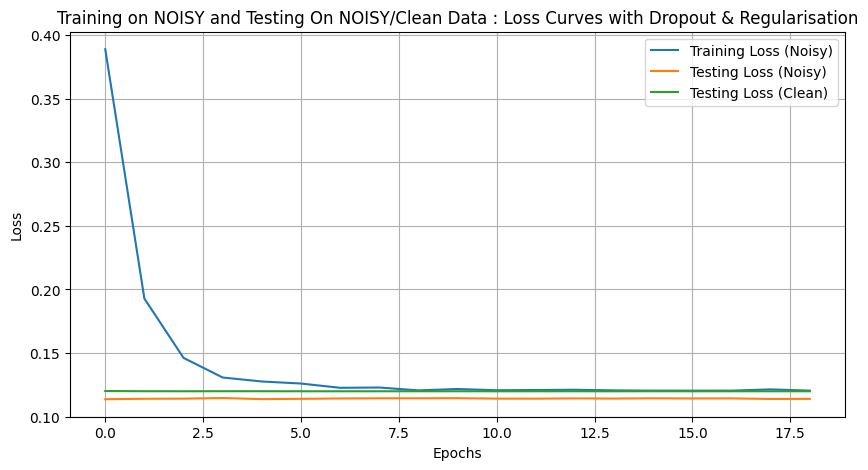

In [33]:
# With L2 Regularisation
# Instantiate and train the modified model
model_dropout_rg = ConvAutoencoderWithDropout()
criterion_noisy_dropout_reg = nn.MSELoss()
optimizer_noisy_dropout_reg = torch.optim.Adam(model_dropout_rg.parameters(), lr=1e-3)

train_losses, test_losses, test_losses_clean_data = train_autoencoder_with_regularization(
    model_dropout_rg, train_loader, test_loader, noisy_test_loader, 
    criterion_noisy_dropout_reg, optimizer_noisy_dropout_reg, epochs=20, l2_reg = False, l1_reg=False, contractive_reg=0.1)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses[1:], label='Training Loss (Noisy)')
plt.plot(test_losses[1:], label='Testing Loss (Noisy)')
plt.plot(test_losses_clean_data[1:], label='Testing Loss (Clean)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training on NOISY and Testing On NOISY/Clean Data : Loss Curves with Dropout & Regularisation')
plt.legend()
plt.grid(True)
plt.show()

## Inferences and Conclusion : State all the key observations and conclusion

The large initial training loss is likely caused by the contractive regularization term. In the first epoch, the gradients may be very large when the network is untrained, leading to a high contractive loss component. As training progresses, the model becomes more stable and regularization losses normalize.

lower the loss during training but rather to improve the generalization of the model—meaning it performs better on unseen data, which is the true test of its ability

Change in accuracy after regularisation ??
- L1 Regularization: Promotes sparsity in the model by driving some weights to zero, helping with feature selection and interpretability.
- L2 Regularization (Weight Decay): Encourages small, evenly distributed weights to prevent overfitting and improve generalization by reducing the impact of noisy features.
- Contractive Regularization: Prevents overfitting by enforcing robustness in the learned representations, making the model less sensitive to small input variations.
- Sigmoid function as Activation Function for the bottleneck layer, this helps in unifying the scales of different layers